For all ball flying throught the air.

-15.363322508648519
[ 25.          24.73911354  24.48160686  24.2274014   23.97642096
  23.7285916   23.48384156  23.24210118  23.00330282  22.76738079
  22.53427127  22.30391225  22.07624347  21.85120636  21.62874396
  21.40880089  21.19132326  20.97625867  20.76355611  20.55316594
  20.34503984  20.13913076  19.93539288  19.73378155  19.53425331
  19.33676579  19.14127768  18.94774874  18.75613972  18.56641236
  18.37852933  18.19245423  18.00815154  17.82558659  17.64472555
  17.46553541  17.28798391  17.11203959  16.93767169  16.76485017
  16.5935457   16.4237296   16.25537386  16.08845108  15.9229345
  15.75879794  15.59601579  15.43456302  15.27441514  15.11554819
  14.95793873  14.8015638   14.64640095  14.49242819  14.339624
  14.18796731  14.03743746  13.88801423  13.73967783  13.59240883
  13.44618822  13.30099736  13.15681797  13.01363215  12.87142233
  12.73017128  12.58986212  12.45047827  12.31200347  12.17442178
  12.03771755  11.90187541  11.76688028  11.63271735  11.49

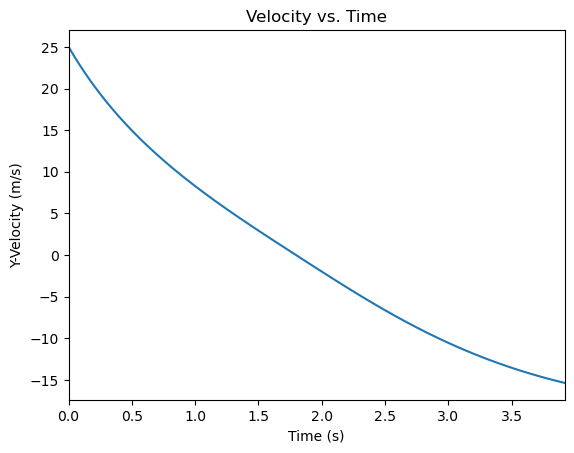

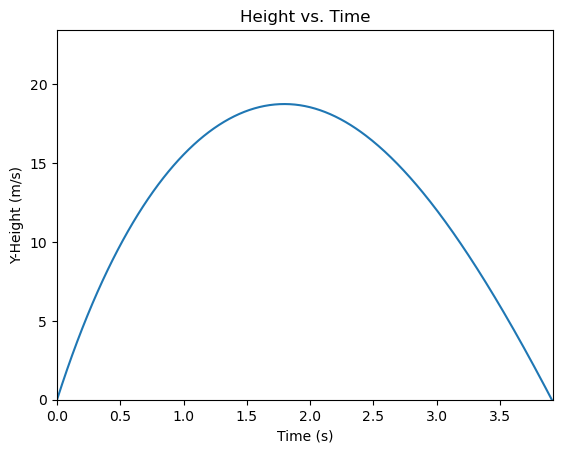

In [56]:
import numpy as np
import matplotlib.pyplot as plt

Cd = 0.47
A = 0.038
p = 1.225
m = 0.42
g = 9.81
angle = 45

dt = 0.01
t = np.arange(0, 10, dt)

hy_array = np.zeros(np.size(t))
vy_array = np.zeros(np.size(t))
vy_array[0] = 25

#
i = 1
while (hy_array[i-1] >= 0) and (i <= (np.size(t) - 1)):
    fy_drag = -0.5 * Cd * p * A * vy_array[i-1]*np.abs(vy_array[i-1])
    ay = fy_drag / m
    vy_change = ay * dt
    vy_array[i] = vy_array[i-1] + vy_change - g*dt
    hy_array[i] = -0.5*g*dt**2 + vy_array[i-1]*dt + hy_array[i-1]
    i += 1
    
index = np.argwhere(hy_array[1:]<=0) + 1
vy_array = vy_array[:index[0][0]+1]
hy_array = hy_array[:index[0][0]+1]
t = t[:index[0][0]+1]

plt.figure()
plt.xlabel("Time (s)")
plt.ylabel("Y-Velocity (m/s)")
plt.title("Velocity vs. Time")
plt.xlim(0, t[index[0][0]])
plt.plot(t, vy_array)

print(np.min(vy_array[:index[0][0]+1]))
print(vy_array)
print(hy_array)


plt.figure()
plt.xlabel("Time (s)")
plt.ylabel("Y-Height (m/s)")
plt.ylim(0, np.max(hy_array)*1.25)
plt.xlim(0, t[index[0][0]])
plt.title("Height vs. Time")
plt.plot(t, hy_array)